In [1]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ridaai","key":"56ea9188675009425c82fe899308a283"}'}

In [2]:
# Install Kaggle
!pip install -q kaggle

# Create kaggle folder
!mkdir -p ~/.kaggle

# Copy kaggle.json to correct location
!cp kaggle.json ~/.kaggle/

# Set correct permission
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!kaggle competitions list


ref                                                                                 deadline             category                reward  teamCount  userHasEntered  
----------------------------------------------------------------------------------  -------------------  ---------------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3       2026-04-15 23:59:00  Featured         2,207,152 Usd       2788           False  
https://www.kaggle.com/competitions/stanford-rna-3d-folding-2                       2026-03-25 23:59:00  Featured            75,000 Usd       1694           False  
https://www.kaggle.com/competitions/deep-past-initiative-machine-translation        2026-03-23 23:59:00  Featured            50,000 Usd       2601           False  
https://www.kaggle.com/competitions/march-machine-learning-mania-2026               2026-03-19 16:00:00  Featured            50,000 Usd       1172           False  
https://ww

In [4]:
!kaggle datasets list -s higgs


ref                                                            title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
ryanholbrook/higgs-boson                                       Higgs Boson                                         1100112219  2020-10-02 23:04:26.343000           1181         12  0.375            
erikbiswas/higgs-uci-dataset                                   HIGGS UCI DATASET                                   2902133066  2021-08-30 04:37:00.577000            913          7  0.88235295       
knight079/higgsb                                               Higgs Boson Dataset                                   59325616  2017-10-17 06:27:15.307000            812          7  0.4117647        
eugen

In [5]:
# Download Higgs UCI dataset
!kaggle datasets download -d erikbiswas/higgs-uci-dataset


Dataset URL: https://www.kaggle.com/datasets/erikbiswas/higgs-uci-dataset
License(s): CC0-1.0
 99% 2.67G/2.70G [00:24<00:00, 144MB/s]
100% 2.70G/2.70G [00:25<00:00, 116MB/s]


In [6]:
# Unzip dataset
!unzip higgs-uci-dataset.zip


Archive:  higgs-uci-dataset.zip
  inflating: HIGGS.csv               


In [7]:
!ls

HIGGS.csv  higgs-uci-dataset.zip  kaggle.json  sample_data


In [13]:
import pandas as pd

df = pd.read_csv("HIGGS.csv", nrows=200000, header=None)

# Check first 5 rows
df.head()



,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


In [14]:
# First column is target
y = df.iloc[:, 0]

# Remaining columns are features
X = df.iloc[:, 1:]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (200000, 28)
Target shape: (200000,)


In [15]:
X.isnull().sum().sum()


np.int64(0)

In [16]:
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit and transform features
X_scaled = scaler.fit_transform(X)

# Check shape
X_scaled.shape


(200000, 28)

In [17]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.30,
    random_state=42
)

# Second split: 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

# Print shapes
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (140000, 28)
Validation shape: (30000, 28)
Test shape: (30000, 28)


In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [19]:
# Define the model
model = keras.Sequential([

    # First hidden layer
    layers.Dense(128, activation='relu', input_shape=(28,)),
    layers.BatchNormalization(),      # helps stabilize learning
    layers.Dropout(0.3),              # prevents overfitting

    # Second hidden layer
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Third hidden layer
    layers.Dense(32, activation='relu'),

    # Output layer (binary classification)
    layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [21]:
# Early stopping (stops training if no improvement)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Reduce learning rate if stuck
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)


In [22]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5806 - loss: 0.6857 - val_accuracy: 0.6660 - val_loss: 0.6066 - learning_rate: 0.0010
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6572 - loss: 0.6180 - val_accuracy: 0.6869 - val_loss: 0.5873 - learning_rate: 0.0010
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6798 - loss: 0.5968 - val_accuracy: 0.6965 - val_loss: 0.5736 - learning_rate: 0.0010
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6921 - loss: 0.5833 - val_accuracy: 0.7000 - val_loss: 0.5656 - learning_rate: 0.0010
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6981 - loss: 0.5750 - val_accuracy: 0.7080 - val_loss: 0.5571 - learning_rate: 0.0010
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6998 - loss: 0.5695 - val_accuracy: 0.7120 - val_loss: 0.5519 - learning_rate: 0.0010
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7091 - loss: 0.5595 -

In [23]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)


938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7319 - loss: 0.5218
Test Accuracy: 0.7345333099365234


In [24]:
import numpy as np

# Get predicted probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int)


938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.73      0.70      0.71     14170
         1.0       0.74      0.76      0.75     15830

    accuracy                           0.73     30000
   macro avg       0.73      0.73      0.73     30000
weighted avg       0.73      0.73      0.73     30000



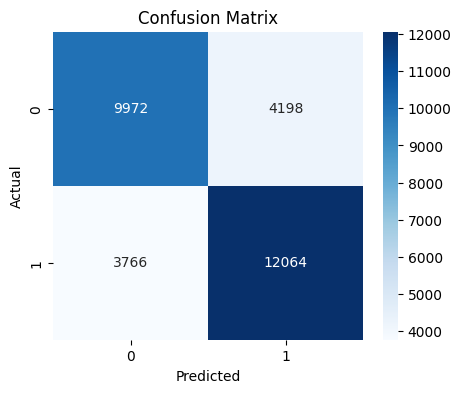

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


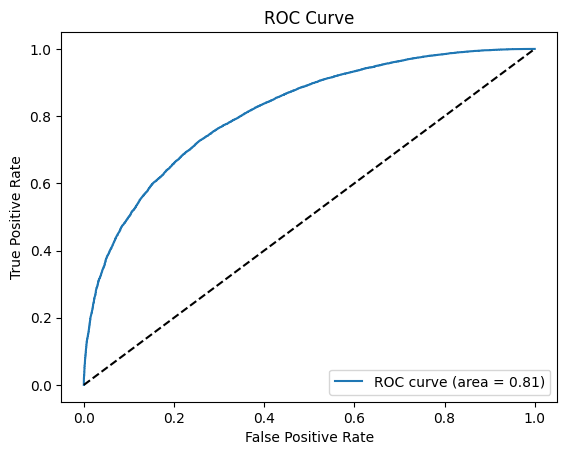

ROC-AUC Score: 0.8149387903674852


In [27]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", roc_auc)


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train on training data
rf.fit(X_train, y_train)

# Predict on test set
rf_pred = rf.predict(X_test)

# Predict probabilities
rf_prob = rf.predict_proba(X_test)[:, 1]

# Accuracy
rf_accuracy = rf.score(X_test, y_test)
print("Random Forest Test Accuracy:", rf_accuracy)

# Classification report
print(classification_report(y_test, rf_pred))

# ROC-AUC
rf_auc = roc_auc_score(y_test, rf_prob)
print("Random Forest ROC-AUC:", rf_auc)



Random Forest Test Accuracy: 0.7216333333333333
              precision    recall  f1-score   support

         0.0       0.71      0.70      0.70     14170
         1.0       0.73      0.74      0.74     15830

    accuracy                           0.72     30000
   macro avg       0.72      0.72      0.72     30000
weighted avg       0.72      0.72      0.72     30000

Random Forest ROC-AUC: 0.8010088198934426


**How did model depth and activation affect performance?**

I used three hidden layers (128 → 64 → 32) with ReLU activation.
The deeper model helped the network learn more complex patterns from the data. ReLU helped the model train faster and avoid vanishing gradient problems.

Using sigmoid in the output layer was suitable for binary classification.
Overall, the depth and activation functions helped the model reach about 73% accuracy.

**What helped mitigate overfitting?**

To reduce overfitting, I used:

Dropout layers (0.3)

Batch Normalization

EarlyStopping

Validation data during training

Because of these techniques, training and validation accuracy stayed close, which shows the model did not overfit too much.

**How did the learning rate and optimizer affect convergence?**

I used the Adam optimizer with a learning rate of 0.001.
Adam helped the model converge smoothly and quickly.

The learning rate was balanced, not too high and not too low, which allowed steady improvement in validation loss during training.

**What would you improve with more time or compute?**

With more time, I would:

Train on the full dataset instead of a subset

Try different architectures and optimizers

Tune hyperparameters

Perform more experiments to improve accuracy

This could potentially increase model performance further.